In [73]:
# import libraries
%matplotlib inline
import pandas as pd 
import numpy as np
import re
import warnings
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# SKlearn to aid in machine learning functions
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [74]:
# ignore warnings
warnings.filterwarnings('ignore')

In [75]:
# Load data file
CSV_FILE = pd.read_csv('Data_Download_1.csv')

In [76]:
# Set the require counties for model
VALID_COUNTIES = ['Nairobi', 'Kiambu', 'Machakos', 'Kajiado'] 

In [77]:
# Repeat counties on empty ward cells
BACKFILL_COUNTIES = ['Nairobi', 'Kiambu', 'Machakos', 'Kajiado']

In [78]:
# Set recommended milestones
WHO_MILESTONES = {
    # 12-17 months
    (12, 17): {
        'min_words'     : 1,      # Child should say at least 1 meaningful word
        'combines_words': False,  # Two-word phrases are NOT yet expected
        'responds_to_name': True, # Should respond when called by name
        'description': (
            "12–17 months: Child should say 1–3 meaningful words "
            "(e.g. 'mama', 'dada', 'no'). Responds to own name. "
            "Points at objects. Imitates sounds."
        )
    },
    # 18-23 months
    (18, 23): {
        'min_words'     : 10,     # WHO: at least 10 words by 18 months
        'combines_words': False,  # Still not expected to combine words yet
        'responds_to_name': True,
        'description': (
            "18–23 months: Child should use at least 10 words. "
            "Identifies familiar objects when named. "
            "Follows simple 1-step instructions."
        )
    },
    # 24- 29 months
    (24, 29): {
        'min_words'     : 50,     # WHO: 50+ words
        'combines_words': True,   # Should NOW be combining two words
        'responds_to_name': True,
        'description': (
            "24–29 months: Child should use 50+ words and begin combining "
            "two words (e.g. 'more milk', 'mama come'). "
            "Strangers should understand ~50% of speech."
        )
    },
    # 30-36 months
     (30, 36): {
        'min_words'     : 100,    # WHO: 100–200+ words
        'combines_words': True,   # 3-word sentences expected
        'responds_to_name': True,
        'description': (
            "30–36 months: Child should use 100–200+ words and form "
            "3-word sentences. Strangers understand ~75% of speech. "
            "Asks simple 'what' and 'where' questions."
        )
    },
}


In [79]:
# Function to determine the age group based on the child's age in months
def get_milestone_band(age_months):
    #Loop through the defined milestone bands to find where the age falls
    for (low, high), band_data in WHO_MILESTONES.items():
           if low <= int(age_months) <= high:
            return (low, high), band_data 
           # if age_months falls outside the defined bands, return None
    return None, None

In [80]:
# Create a data cleaning pipeline
# Clean Income data
def clean_income(value):
    # if income is empty return NaN
    if pd.isna(value):
        return np.nan
    # Remove non-numeric characters (e.g. currency symbols, commas)
    value = str(value).strip().lower()
    value = value.replace(',', '')
    value = value.replace('ksh', '')
    value = value.replace('kes', '')
    value = value.strip()
    # All 0, values should be treated as missing values
    if value in ('', '0', '00', 'nan'):
        return np.nan
    # for values like '10k-20k', take the average of the range
    if re.match(r'^\d+[-\u2013]\d+$', value):
        numbers = re.findall(r'\d+', value)
        return (float(numbers[0]) + float(numbers[1])) / 2
    # less than format
    if value.startswith('<'):
        number = re.findall(r'\d+', value)
        return float(number[0]) if number else np.nan
    # greater than format
    if value.startswith('>'):
        number = re.findall(r'\d+', value)
        return float(number[0]) if number else np.nan
    # Multipliers
    multiplier = 1
    if value.endswith('k'):
        multiplier = 1_000
        value = value[:-1]
    elif value.endswith('m'):
        multiplier = 1_000_000
        value = value[:-1]
    # for any remaining, extract it
    numbers = re.findall(r'[\d.+]+', value)
    if not numbers:
        return np.nan
    try:
        return float(numbers[0]) * multiplier
    except ValueError:
        return np.nan


In [81]:
def clean_caregiver_age(value):
    # Caregiver age cleaning pipeline
    # if age is empty or is a float
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    # if age ranges from 20-30, take the average
    if re.match(r'^\d{2}[-\u2013]\d{2}$', value):
        numbers = re.findall(r'\d+', value)
        return (float(numbers[0]) + float(numbers[1])) / 2
    # if age was entered in months, convert to years
    if 'month' in value:
        numbers = re.findall(r'\d+', value)
        if numbers:
            return float(numbers[0]) / 12
        else:
            return np.nan
    # handle single or multiple numbers
    numbers = re.findall(r'\d+', value)
    if len(numbers) == 1:
        return float(numbers[0])
    elif len(numbers) == 2:
        return (float(numbers[0]) + float(numbers[1])) / 2
    else:
        return np.nan
    # different years formats
    if 'year' in value or 'yr' in value:
        numbers = re.findall(r'\d+', value)
        if numbers:
            return float(numbers[0])
    # plain numbers
    numbers = re.findall(r'\d+', value)
    if not numbers:
        return np.nan
    age = float(numbers[0])
    # for obvious outliers
    if age < 10 or age > 80:
        return age
 
   

In [82]:
# Clean screen introduction pipeline
def clean_screen_intro(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    # incase child has not been introduced to screens
    if value in ('no', 'none', 'not yet', 'n/a', 'na'):
        return np.nan
    # extract numbers
    numbers = re.findall(r'\d+', value)
    # if not numbers are found, return NaN
    if not numbers:
        return np.nan
    # if entry is in years
    if 'year' in value or 'yr' in value:
        return float(numbers[0]) * 12
    # if already in months, extract the number
    if 'month' in value:
        return float(numbers[0])
    # for ranges like 5-7 months, take the average
    if len(numbers) >= 2:
        return (float(numbers[0]) + float(numbers[1])) / 2    
# if it's just a single number, return it
    return float(numbers[0])
    



In [83]:
# Clean screen time to constant values pipeline
SCREEN_TiME_MAP = {
    'less than 30min': 0.25,
    '30 min': 0.5,
    '1 hour': 1.0,
    '2 hours': 2.0,
    '3 hours': 3.0,
    '4 hours': 4.0,
    'more than 4 hours': 5.0,
}
def clean_screen_time(value):
    # convert text options to numeric options
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    # confirm if map keys are well aligned
    for key, hours in SCREEN_TiME_MAP.items():
        if key in value:
            return hours
    # allow to extract directly
    numbers = re.findall(r'\d+', value)
    return float(numbers[0]) if numbers else np.nan


In [84]:
# Clean how many words the child can say pipeline
def clean_word_count(value):
    WORD_COUNT_MAP = {
        'below 5 words': 2,    # Midpoint: ~2 words
        'below 5': 2,
        '5 - 20': 12,          # Midpoint: 12 words
        '5-20': 12,
        '20 - 50': 35,         # Midpoint: 35 words
        '20-50': 35,
        '50 -100': 75,         # Midpoint: 75 words
        '50-100': 75,
        '100 - 200': 150,      # Midpoint: 150 words
        '100-200': 150,
        'over 200': 250,       # Representative: 250 words
    }
    if pd.isna(value):
        return np.nan
    value = str(value).strip().lower()
    for key, count in WORD_COUNT_MAP.items():
        if key in value:
            return count
    # If not found in map, try to extract a number directly
    numbers = re.findall(r'\d+', value)
    return float(numbers[0]) if numbers else np.nan
def check_word_delay(word_count_raw, min_words_required):
    if pd.isna(word_count_raw):
        return 0.0
    text = str(word_count_raw).strip().lower()
    # extract all numbers from the text
    numbers = re.findall(r'\d+', text)
    # Range Bounds

    if 'below' in text or 'under' in text or 'less' in text:
        # 'below 5 words' → range is 0 to 5
        range_min = 0
        range_max = float(numbers[0]) if numbers else 0

    elif 'over' in text or 'above' in text or 'more' in text:
        # 'over 200' → range is 200 to infinity 
        range_min = float(numbers[0]) if numbers else 9999
        range_max = 9999

    elif len(numbers) >= 2:
        # Standard range like '20 - 50' or '100-200'
        range_min = float(numbers[0])
        range_max = float(numbers[1])

    elif len(numbers) == 1:
        # Single number extract
        exact_value = float(numbers[0])
        return 0.0 if exact_value >= min_words_required else 1.0
    
    else:        # No numbers found, cannot determine delay
        return 0.0  
    # Comparing against WHO milestones
    if range_max < min_words_required:
        return 1.0  # Delayed 
    elif range_min >= min_words_required:
        return 0.0  # Not delayed
    else:
        # If range is partially below and partially above threshold, assume delayed
        return 0.5  # Uncertain, but leaning towards delayed

In [85]:
# Cleaning verbal interaction pipeline
VERBAL_INTERACTION_MAP = {
    'less than 15 min' : 0,   # Lowest — very little verbal input
    '15 min - 30 min'  : 1,
    '30 min - 1 hour'  : 2,
    'over 1 hour'      : 3,   # Highest — rich verbal environment
}

In [86]:
# Cleaning co-viewing map
CO_VIEW_MAP = {
    'never'     : 0,   # Child watches screens alone
    'rarely'    : 1,
    'sometimes' : 2,
    'always'    : 3    # Caregiver always co-views and discusses
}

In [87]:
# Load dataset
def load_data():
    return pd.read_csv('Data_Download_1.csv')
print(f"\n[Step 1] Data loading function defined successfully.")


[Step 1] Data loading function defined successfully.


In [88]:
# Read data file
df = pd.read_csv('Data_Download_1.csv')

In [89]:
# Inspect file
print(df.head())
print(df.info())
print(df.describe())

                      Timestamp Total score  \
0  2026/02/11 10:35:08 AM GMT+3    0.00 / 0   
1  2026/02/11 11:31:22 AM GMT+3    0.00 / 0   
2  2026/02/11 12:09:02 PM GMT+3    0.00 / 0   
3  2026/02/11 12:26:34 PM GMT+3    0.00 / 0   
4   2026/02/13 7:54:10 PM GMT+3    0.00 / 0   

    I have read and understood the information above and agree to participate.    \
0                                                Yes                               
1                                                Yes                               
2                                                Yes                               
3                                                Yes                               
4                                                Yes                               

    I have read and understood the information above and agree to participate.   [Score]  \
0                                             -- / 0                                       
1                           

In [90]:
# remove autogenerated score columns
columns_to_keep = [
    col for col in df.columns
    if '[Score]' not in col and '[Feedback]' not in col
]

df = df[columns_to_keep].copy()
print(df.columns)

Index(['Timestamp', 'Total score',
       '  I have read and understood the information above and agree to participate.  ',
       'Which County  do you live in?', 'Nairobi County Wards',
       'Child’s Age (in months): ', 'Gender:',
       'Birth order (1st born, 2nd born etc.):',
       'Any known medical conditions or hearing issues?',
       'Age when introduced to screen media (in months):',
       'Average screen time per day  (weekdays):',
       'Average screen time per day  (weekends):',
       'Type of device(s) mostly used:', 'Type of content mostly viewed:',
       ' Does the caregiver co-view or discuss content with the child?',
       'How often do you talk, sing, or read to your child each day?',
       'Does your child respond when spoken to or called by name?',
       'Does your child combine words (e.g., “mama come”)?',
       'Approximate number of words your child can clearly say:',
       'Has a teacher or health worker ever raised concern about your child’s speec

In [91]:
# Drop responses from counties outside the target area
county_column = 'Which County  do you live in?'
rows_before   = len(df)
df = df[df[county_column].isin(VALID_COUNTIES)].copy()
rows_dropped  = rows_before - len(df)

if rows_dropped > 0:
    print(f"  Dropped {rows_dropped} row(s) outside study counties "
          f"(kept: {VALID_COUNTIES}).")

  Dropped 2 row(s) outside study counties (kept: ['Nairobi', 'Kiambu', 'Machakos', 'Kajiado']).


In [92]:
# Fill counties on empty ward cells
county_column = 'Which County  do you live in?'
ward_column = 'Nairobi County Wards'
backfill_mask = (
    df[ward_column].isna() &
    df[county_column].isin(VALID_COUNTIES)
)
df.loc[backfill_mask, ward_column] = df.loc[backfill_mask, county_column]
backfilled_count = backfill_mask.sum()

if backfilled_count > 0:
    print(f"  Backfilled ward column for {backfilled_count} row(s) "
          f"(Kiambu / Machakos / Kajiado with empty ward).")

  Backfilled ward column for 6 row(s) (Kiambu / Machakos / Kajiado with empty ward).


In [93]:
# drop rows where medical condition is Yes
medical_column = 'Any known medical conditions or hearing issues?'

if medical_column in df.columns:
        medical_yes_mask = (
            df[medical_column].str.strip().str.lower() == 'yes'
        )
        n_medical_dropped = medical_yes_mask.sum()
        df = df[~medical_yes_mask].copy()  

        if n_medical_dropped > 0:
            print(f"  Dropped {n_medical_dropped} row(s) where caregiver "
                  f"reported known medical or hearing conditions.")
        else:
            print(f"  Medical/hearing filter: no rows dropped "
                  f"(no 'Yes' responses found).")
else:
        print(f"  Warning: column '{medical_column}' not found — "
              f"medical filter could not be applied.")

  Dropped 2 row(s) where caregiver reported known medical or hearing conditions.


In [94]:
# Rename Columns for easier access
rename_map = {
        'Timestamp'                                                     : 'timestamp',
        'Which County  do you live in?'                                 : 'county',
        'Nairobi County Wards'                                          : 'ward',
        'Relationship to child'                                         : 'caregiver_relation',
        'Age'                                                           : 'caregiver_age_raw',
        'Your Age'                                                      : 'caregiver_age_raw',              
        'Education Level:'                                              : 'education',
        'Your Education Level:'                                         : 'education',
        'Occupation'                                                    : 'occupation',
        'Estimated  income per month'                                   : 'income_raw',
        'Number of children under 5 years in household'                 : 'num_children_u5',
         'Child\u2019s Age (in months): '                               : 'child_age_months',
        'Gender:'                                                       : 'child_gender',
        'Birth order (1st born, 2nd born etc.):'                       : 'birth_order',
        'Any known medical conditions or hearing issues?'               : 'medical_conditions',
        'Age when introduced to screen media (in months):'             : 'screen_intro_age_raw',
        'Average screen time per day  (weekdays):'                     : 'screen_weekday',
        'Average screen time per day  (weekends):'                     : 'screen_weekend',
        'Type of device(s) mostly used:'                               : 'device_type',
        'Type of content mostly viewed:'                               : 'content_type',
        ' Does the caregiver co-view or discuss content with the child?': 'co_view',
        'How often do you talk, sing, or read to your child each day?' : 'verbal_interaction',
        'Does your child respond when spoken to or called by name?'    : 'responds_to_name',
        'Does your child combine words (e.g., \u201cmama come\u201d)?': 'combines_words',
        'Approximate number of words your child can clearly say:'      : 'word_count_range',
        'Has a teacher or health worker ever raised concern about your child\u2019s speech?': 'concern_raised',
        'Would you be interested in using a simple mobile tool to check your child\u2019s speech progress?': 'wants_app',
}
rename_map = {k: v for k, v in rename_map.items() if k in df.columns}
df.rename(columns=rename_map, inplace=True)

print(f"  Loaded {len(df)} responses with {len(df.columns)} columns.")

  Loaded 37 responses with 27 columns.


In [95]:
# Ensure columns are being cleaned properly
def verify_cleaning(df, raw_col, clean_col, n_samples=6):
    # stop if columns not in dataframe
    assert raw_col in df.columns, (
        f"\n\n  ERROR: Column '{raw_col}' was not found in the dataframe.\n"
        f"  Available columns: {list(df.columns)}\n"
        f"  Check that your CSV file matches the expected column names."
    )
    # confirm that clean_col exists
    assert clean_col in df.columns, (
        f"\n\n  ERROR: Column '{clean_col}' was not found in the dataframe.\n"
        f"  Available columns: {list(df.columns)}\n"
        f"  Check that your CSV file matches the expected column names."
    )
    # Allow print for verification header
    print(f"\n  [Cleaning: {clean_col}]")
    print(f"  Column found : '{raw_col}'  ->  writing to: '{clean_col}'")
    # Build sample table before and after cleaning for verification
    has_raw = df[raw_col].notna()
    sample  = df[has_raw][[raw_col, clean_col]].drop_duplicates().head(n_samples)
    print(f"  Sample before -> after:")
    for _, row in sample.iterrows():
        raw_val   = repr(str(row[raw_col]))   # repr() adds quotes so spaces are visible
        clean_val = row[clean_col]
        # Format the cleaned value — show NaN clearly so failures stand out
        if pd.isna(clean_val):
            clean_str = "NaN  (could not parse)"
        elif isinstance(clean_val, float) and clean_val == int(clean_val):
            clean_str = f"{clean_val:,.0f}"   # Format whole numbers with commas
        elif isinstance(clean_val, float):
            clean_str = f"{clean_val:.4f}"
        else:
            clean_str = str(clean_val)

        print(f"    {raw_val:<25}  ->  {clean_str}")

    # ── Print the parse success rate ──────────────────────────────────
    total_raw    = df[raw_col].notna().sum()        # Non-blank raw values
    total_parsed = df[clean_col].notna().sum()      # Successfully parsed values
    total_failed = total_raw - total_parsed         # Values that became NaN

    if total_raw > 0:
        pct = total_parsed / total_raw * 100
        print(f"  Parsed: {total_parsed} / {total_raw}  ({pct:.0f}%)  "
              f"|  Failed to parse: {total_failed}")
        # warn if values failed to parse
        if total_failed > 0:
            # Find the rows where raw value exists but cleaned value is NaN
            failed_mask   = has_raw & df[clean_col].isna()
            failed_values = df.loc[failed_mask, raw_col].unique()
            print(f"  *** WARNING: {total_failed} value(s) could not be parsed:")
            for v in failed_values:
                print(f"      '{v}'")
            print(f"  These will be treated as missing (NaN) in the model.")


def clean_data(df):
    return df



In [96]:
# Ensure columns are clean
print("\n[Step 2] Cleaning data...")
print("  Each column is verified: source name shown, sample values printed.")
print("  Any values that cannot be parsed are listed as warnings.")

    # Make a copy 
df = df.copy()


[Step 2] Cleaning data...
  Each column is verified: source name shown, sample values printed.
  Any values that cannot be parsed are listed as warnings.


In [97]:
# Clean income column
df['income'] = df['income_raw'].apply(clean_income)
verify_cleaning(df, raw_col='income_raw', clean_col='income')


  [Cleaning: income]
  Column found : 'income_raw'  ->  writing to: 'income'
  Sample before -> after:
    '50,000'                   ->  50,000
    '70000'                    ->  70,000
    '200k'                     ->  200,000
    '15000'                    ->  15,000
    '0'                        ->  NaN  (could not parse)
    '50k'                      ->  50,000
  Parsed: 26 / 27  (96%)  |  Failed to parse: 1
  *** WARNING: 1 value(s) could not be parsed:
      '0'
  These will be treated as missing (NaN) in the model.


In [98]:
# Clean Caregiver age column
df['caregiver_age'] = df['caregiver_age_raw'].apply(clean_caregiver_age)
verify_cleaning(df, raw_col='caregiver_age_raw', clean_col='caregiver_age')


  [Cleaning: caregiver_age]
  Column found : 'caregiver_age_raw'  ->  writing to: 'caregiver_age'
  Sample before -> after:
    '36'                       ->  36
    '25'                       ->  25
    '4 years'                  ->  4
    '69'                       ->  69
    '33'                       ->  33
    '32'                       ->  32
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [99]:
# Screen weekday hours column
df['screen_weekday_hrs'] = df['screen_weekday'].apply(clean_screen_time)
verify_cleaning(df, raw_col='screen_weekday', clean_col='screen_weekday_hrs')


  [Cleaning: screen_weekday_hrs]
  Column found : 'screen_weekday'  ->  writing to: 'screen_weekday_hrs'
  Sample before -> after:
    '3 hours'                  ->  3
    'More than 4 hours'        ->  4
    '1 hour'                   ->  1
    'Less than 30 min'         ->  0.5000
    '2 hours'                  ->  2
    '4 hours'                  ->  4
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [100]:
# Screen introduction age column
df['screen_intro_months'] = df['screen_intro_age_raw'].apply(clean_screen_intro)
verify_cleaning(df, raw_col='screen_intro_age_raw', clean_col='screen_intro_months')


  [Cleaning: screen_intro_months]
  Column found : 'screen_intro_age_raw'  ->  writing to: 'screen_intro_months'
  Sample before -> after:
    '3'                        ->  3
    '4'                        ->  4
    '13'                       ->  13
    '8 years'                  ->  96
    'Not introduced'           ->  NaN  (could not parse)
    '6'                        ->  6
  Parsed: 35 / 37  (95%)  |  Failed to parse: 2
  *** WARNING: 2 value(s) could not be parsed:
      'Not introduced'
      'In months '
  These will be treated as missing (NaN) in the model.


In [101]:
# Screen weekend hours column
df['screen_weekend_hrs'] = df['screen_weekend'].apply(clean_screen_time)
verify_cleaning(df, raw_col='screen_weekend', clean_col='screen_weekend_hrs')



  [Cleaning: screen_weekend_hrs]
  Column found : 'screen_weekend'  ->  writing to: 'screen_weekend_hrs'
  Sample before -> after:
    '2 hours'                  ->  2
    'More than 4 hours'        ->  4
    'Less than 30 min'         ->  0.5000
    '1 hour'                   ->  1
    '4 hours'                  ->  4
    '3 hours'                  ->  3
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [102]:
# Word Count column
# clean the corrupted colums first
if 'word_count_range' in df.columns:
        df['word_count_range'] = df['word_count_range'].replace(
            {'20-May': '5 - 20',   # Excel corrupted '5 - 20' to '20-May'
             'May-20': '5 - 20'}   # Alternative Excel date format
        )

df['word_count'] = df['word_count_range'].apply(clean_word_count)
verify_cleaning(df, raw_col='word_count_range', clean_col='word_count')


  [Cleaning: word_count]
  Column found : 'word_count_range'  ->  writing to: 'word_count'
  Sample before -> after:
    '20 - 50'                  ->  35
    '5 - 20'                   ->  12
    'Over 200'                 ->  250
    '100 - 200'                ->  150
    'Below 5 words'            ->  2
    '50 -100'                  ->  75
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [103]:
# verbal interaction column
df['verbal_score'] = (
        df['verbal_interaction'].str.strip().str.lower().map(VERBAL_INTERACTION_MAP)
    )
verify_cleaning(df, raw_col='verbal_interaction', clean_col='verbal_score')



  [Cleaning: verbal_score]
  Column found : 'verbal_interaction'  ->  writing to: 'verbal_score'
  Sample before -> after:
    'Less than 15 min'         ->  0
    '30 min - 1 hour'          ->  2
    'Over 1 hour'              ->  3
    '15 min - 30 min'          ->  1
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [104]:
# Coviewing column
df['coview_score'] = (
        df['co_view'].str.strip().str.lower().map(CO_VIEW_MAP)
    )
verify_cleaning(df, raw_col='co_view', clean_col='coview_score')


  [Cleaning: coview_score]
  Column found : 'co_view'  ->  writing to: 'coview_score'
  Sample before -> after:
    'Rarely'                   ->  1
    'Sometimes'                ->  2
    'Never'                    ->  0
    'Always'                   ->  3
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [105]:
# Columns with yes/no
def yes_no_to_binary(text_value):
        cleaned = str(text_value).strip().lower()
        if cleaned == 'yes':
            return 1
        elif cleaned == 'no':
            return 0
        else:
            return np.nan 
# clean each yes/no column
df['responds_to_name_bin'] = df['responds_to_name'].apply(yes_no_to_binary)
verify_cleaning(df, raw_col='responds_to_name', clean_col='responds_to_name_bin', n_samples=2)

df['combines_words_bin']   = df['combines_words'].apply(yes_no_to_binary)
verify_cleaning(df, raw_col='combines_words',   clean_col='combines_words_bin',   n_samples=2)

df['concern_raised_bin']   = df['concern_raised'].apply(yes_no_to_binary)
verify_cleaning(df, raw_col='concern_raised',   clean_col='concern_raised_bin',   n_samples=2)


  [Cleaning: responds_to_name_bin]
  Column found : 'responds_to_name'  ->  writing to: 'responds_to_name_bin'
  Sample before -> after:
    'Yes'                      ->  1
    'No'                       ->  0
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0

  [Cleaning: combines_words_bin]
  Column found : 'combines_words'  ->  writing to: 'combines_words_bin'
  Sample before -> after:
    'No'                       ->  0
    'Yes'                      ->  1
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0

  [Cleaning: concern_raised_bin]
  Column found : 'concern_raised'  ->  writing to: 'concern_raised_bin'
  Sample before -> after:
    'No'                       ->  0
    'Yes'                      ->  1
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [106]:
# Education level column
education_map = {
        'primary'            : 0,
        'secondary'          : 1,
        'college/university' : 2,
    }
df['education_ord'] = df['education'].str.strip().str.lower().map(education_map)
verify_cleaning(df, raw_col='education', clean_col='education_ord')


  [Cleaning: education_ord]
  Column found : 'education'  ->  writing to: 'education_ord'
  Sample before -> after:
    'Primary'                  ->  0
    'College/University'       ->  2
    'Secondary'                ->  1
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [107]:
# Gender column
gender_map = {'male': 1, 'female': 0}
df['gender_bin'] = df['child_gender'].str.strip().str.lower().map(gender_map)
verify_cleaning(df, raw_col='child_gender', clean_col='gender_bin', n_samples=2)



  [Cleaning: gender_bin]
  Column found : 'child_gender'  ->  writing to: 'gender_bin'
  Sample before -> after:
    'Female'                   ->  0
    'Male'                     ->  1
  Parsed: 37 / 37  (100%)  |  Failed to parse: 0


In [108]:
# Create screen average column
print(f"\n  [Calculating: screen_avg_hrs]")
print(f"  Formula: (screen_weekday_hrs × 5 + screen_weekend_hrs × 2) ÷ 7")
df['screen_avg_hrs'] = (
        df['screen_weekday_hrs'].fillna(0) * 5 +
        df['screen_weekend_hrs'].fillna(0) * 2
    ) / 7
above_who = (df['screen_avg_hrs'] > 2).sum()
print(f"  Result range: {df['screen_avg_hrs'].min():.2f} – "
          f"{df['screen_avg_hrs'].max():.2f} hrs/day")
print(f"  {above_who} children ({above_who/len(df)*100:.0f}%) exceed WHO 2hr guideline")


  [Calculating: screen_avg_hrs]
  Formula: (screen_weekday_hrs × 5 + screen_weekend_hrs × 2) ÷ 7
  Result range: 0.50 – 4.00 hrs/day
  10 children (27%) exceed WHO 2hr guideline


In [109]:
# Birth order column
print(f"\n  [Cleaning: birth_order_clean]")
print(f"  Column found: 'birth_order'  ->  writing to: 'birth_order_clean'")
df['birth_order_clean'] = pd.to_numeric(
        df['birth_order'], errors='coerce'
    ).clip(upper=5)
raw_max = pd.to_numeric(df['birth_order'], errors='coerce').max()
print(f"  Raw max value: {raw_max:.0f}  ->  capped at 5")
print(f"  Distribution: {df['birth_order_clean'].value_counts().sort_index().to_dict()}")



  [Cleaning: birth_order_clean]
  Column found: 'birth_order'  ->  writing to: 'birth_order_clean'
  Raw max value: 10  ->  capped at 5
  Distribution: {1: 21, 2: 8, 3: 3, 4: 3, 5: 2}


In [110]:
# Number of children under 5 column
word_to_num = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5}

def parse_num_children(value):
        """Convert text or number to integer count of children under 5."""
        if pd.isna(value):
            return np.nan
        text = str(value).strip().lower()
        if text in word_to_num:
            return word_to_num[text]
        try:
            return float(text)
        except ValueError:
            return np.nan

df['num_children_u5'] = df['num_children_u5'].apply(parse_num_children)

In [111]:
# Flag Nairobi
df['in_nairobi'] = df['county'].str.strip().str.lower().apply(
        lambda county: 1 if 'nairobi' in str(county) else 0
    )

In [112]:
# Summary of Columns
valid = df['concern_raised_bin'].notna().sum()
print(f"\n  {'─' * 50}")
print(f"  Cleaning complete. {valid} valid responses ready for analysis.")
print(f"  {'─' * 50}")




  ──────────────────────────────────────────────────
  Cleaning complete. 37 valid responses ready for analysis.
  ──────────────────────────────────────────────────


In [113]:
# Milestone Checking
def check_milestone_flags(row):
    # Get the child's age in months
    age = row.get('child_age_months', np.nan)

    # if child age is missing, return zero
    if pd.isna(age):
        return {
            'milestone_word_delay'   : 0,
            'milestone_combine_delay': 0,
            'milestone_respond_delay': 0,
            'milestone_delay_count'  : 0,
            'milestone_band'         : 'Unknown',
            'milestone_description'  : 'Age not recorded',
        }

    # Determine the milestone band based on age
    band_key, band_data = get_milestone_band(int(age))
    if band_data is None:
        return {
            'milestone_word_delay'   : 0,
            'milestone_combine_delay': 0,
            'milestone_respond_delay': 0,
            'milestone_delay_count'  : 0,
            'milestone_band'         : 'Out of range',
            'milestone_description'  : 'Age outside 12–36 month study scope',
        }

    # word count delay
    word_count_raw = row.get('word_count_range', np.nan)
    word_delay = check_word_delay(word_count_raw, band_data['min_words'])

    # word combining delay
    combines = row.get('combines_words_bin', np.nan)
    if pd.isna(combines):
        combine_delay = 0
    elif band_data['combines_words']:
        combine_delay = int(combines == 0)
    else:
        combine_delay = 0

    # responds-to-name delay
    responds = row.get('responds_to_name_bin', np.nan)
    if pd.isna(responds):
        respond_delay = 0
    elif band_data['responds_to_name']:
        respond_delay = int(responds == 0)
    else:
        respond_delay = 0

    total_delays = word_delay + combine_delay + respond_delay

    return {
        'milestone_word_delay'   : word_delay,
        'milestone_combine_delay': combine_delay,
        'milestone_respond_delay': respond_delay,
        'milestone_delay_count'  : total_delays,

        'word_status'    : delay_status(word_delay),
        'combine_status' : ("On track" if combine_delay == 0 else "Delayed"),
        'respond_status' : ("On track" if respond_delay == 0 else "Delayed"),

        # Band information
        'milestone_band'         : f"{band_key[0]}–{band_key[1]} months",
        'milestone_description'  : band_data['description'],
    }

In [114]:
# Engineering functions
def engineer_label(df):
    print("\n[Step 3] Applying WHO milestones and engineering labels...")

    df = df.copy()
    # ensure milestones are checked at every row
    milestone_results = df.apply(check_milestone_flags, axis=1)
    milestone_df = pd.DataFrame(list(milestone_results))
    for column_name in milestone_df.columns:
        df[column_name] = milestone_df[column_name].values

    # Concern raised by health worker or teacher
    df['flag_concern'] = (df['concern_raised_bin'] == 1).astype(int)
    # Average screen time above WHO recommendation
    df['flag_screen_time'] = (df['screen_avg_hrs'] > 2).astype(int)
    # Low verbal interaction score
    df['flag_verbal'] = (df['verbal_score'] <= 1).astype(int)
    # Screen introduction before 12 months
    df['flag_early_screen'] = (df['screen_intro_months'] < 12).astype(int)
    # Summation of all risk factors
    df['behavioural_flag_count'] = (
        df['flag_concern'] +
        df['flag_screen_time'] +
        df['flag_verbal'] +
        df['flag_early_screen']
    )
    # Final binary label
    df['speech_delay_label'] = (
        (df['milestone_delay_count'] >= 0.5) |
        (df['behavioural_flag_count'] >= 2)
    ).astype(int)

    # Assigning severity levels
    def assign_severity(row):
        m = row["milestone_delay_count"]
        b = row["behavioural_flag_count"]

        # Calculating vocabulary gap
        word_count = row.get("word_count", np.nan)
        age = row.get("child_age_months", np.nan)

        vocab_gap_pct = 0.0

        if not pd.isna(age) and not pd.isna(word_count):
            _, band_data_sev = get_milestone_band(int(age))

            if (band_data_sev is not None and
                    word_count < band_data_sev["min_words"] and
                    band_data_sev["min_words"] > 0):

                vocab_gap_pct = (
                    (band_data_sev["min_words"] - word_count)
                    / band_data_sev["min_words"]
                )

        if (m >= 2 or
                (m >= 1 and b >= 2) or
                vocab_gap_pct >= 0.50):
            return "HIGH"

        # MODERATE: 1 milestone missed (gap < 50%), or 2+ behavioural flags
        elif m >= 1 or b >= 2:
            return "MODERATE"

        # LOW: behavioural flags only, no milestone delays
        elif b >= 1:
            return "LOW"

        # NONE: no flags, no delays
        else:
            return "NONE"

    df['severity'] = df.apply(assign_severity, axis=1)

    # Summary of labels
    n_risk = df['speech_delay_label'].sum()
    n_total = len(df)
    severity = df['severity'].value_counts().to_dict()

    print(f"  At-risk : {n_risk} ({n_risk / n_total * 100:.0f}%)")
    print(f"  Low-risk: {n_total - n_risk} ({(n_total - n_risk) / n_total * 100:.0f}%)")
    print(f"  Severity breakdown: {severity}")

    return df


In [115]:
# Prepare features for modeling
FEATURES = [
    # WHO Feautures
    'milestone_word_delay',      # 1 if vocabulary below WHO minimum for age
    'milestone_combine_delay',   # 1 if not combining words when WHO expects it
    'milestone_respond_delay',   # 1 if not responding to own name
    'milestone_delay_count',     # Total count of milestone delays
    # Screen time features
    'screen_avg_hrs',            # Average screen time per day
    'screen_intro_months',       # Age at which screen time was introduced
    # Caregiver interaction features
    'verbal_score',              # Verbal interaction score (0-3)
    'coview_score',              # Co-viewing score (0-3)
    # Child Demographics
    'child_age_months',          # Child's age
    'gender_bin',                # male or female
    'birth_order_clean',         # Birth order of the child
    # Houselhold features
    'num_children_u5',           # Number of children under 5 in the household
    'education_ord',             # Caregiver education level (ordinal)
    'income_log',                # Cleaned income value 
]
TARGET = 'speech_delay_label'  # Binary target variable indicating speech delay risk

def delay_status(delay_value):
    """Convert delay value to status string."""
    if delay_value == 0:
        return "On track"
    elif delay_value == 1:
        return "Delayed"
    else:
        return "Uncertain"

def prepare_features(df):
    print("\n[Step 4] Preparing features...")
    
    # Income log transformation since income is very skewed
    df = df.copy()
    if "income" in df.columns:
        df["income_log"] = np.log10(df["income"].replace(0, np.nan))
        n_income  = df["income_log"].notna().sum()
        n_missing = df["income_log"].isna().sum()
        print(f"  Income (log10): {n_income} values transformed, "
              f"{n_missing} missing (will be imputed with median log-income)")
    else:
        print("  Warning: income column not found — income_log will be skipped")

    available_features = [f for f in FEATURES if f in df.columns]
    missing_features   = [f for f in FEATURES if f not in df.columns]

    if missing_features:
        print(f"  Warning: these features not found and will be skipped: {missing_features}")

    # X = the input table
    X = df[available_features].copy()

    # y = the output column
    y = df[TARGET].copy()

    # Drop rows where the target label is missing
    valid_rows = y.notna()
    X = X[valid_rows]
    y = y[valid_rows]

    print(f"  {len(available_features)} features · {len(X)} usable samples.")

    return X, y, available_features


In [116]:
# Build model for pipleine (help in imptuing and scaling)
def build_pipeline(model):
 return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # fill missing values
        ('scaler',  StandardScaler()),                  # scale features
        ('model',   model),                             # actual model
    ])

In [117]:
# Training and evaluating function
def train_and_evaluate(X, y):
    print("\n[Step 5] Training models with cross-validation...")
    # Define models to train
    models = {
        'Logistic Regression': LogisticRegression(
            max_iter=1000,              # Allow enough iterations to converge
            class_weight='balanced',   # Handle class imbalance
            random_state=42            # Set seed for reproducibility
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,          # 100 decision trees in the forest
            class_weight='balanced',
            random_state=42
        ),
        'Decision Tree': DecisionTreeClassifier(
            max_depth=4,               # Limit depth to prevent overfitting
            class_weight='balanced',
            random_state=42
        ),
    }

    # Determine the number of splits for cross-validation based on dataset size
    minority_class_size = y.value_counts().min()
    n_splits = min(5, int(minority_class_size))

    # Fallback for datasets with very few samples in the minority class
    if n_splits < 2:
        n_splits = 2
        print(
            f"  Warning: only {minority_class_size} sample(s) in the minority class. "
            f"Using train-all evaluation (not cross-validated)."
        )

        results = {}
        for name, model in models.items():
            pipeline = build_pipeline(model)
            pipeline.fit(X, y)
            y_pred = pipeline.predict(X)
            results[name] = {
                'accuracy': accuracy_score(y, y_pred),
                'f1': f1_score(y, y_pred, zero_division=0),
                'precision': 0.0,
                'recall': 0.0,
                'roc_auc': 0.5,
                'acc_std': 0.0,
            }

            print(f"  {name}: Acc={results[name]['accuracy']:.2f}  F1={results[name]['f1']:.2f}")

        return results, models

    # Stratified k-fold cross-validation for imbalanced datasets
    cross_validator = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,       # Shuffle data before splitting to reduce bias
        random_state=42
    )

    results = {}
    for name, model in models.items():
        pipeline = build_pipeline(model)

        # Perform cross-validation
        scores = cross_validate(
            pipeline, X, y,
            cv=cross_validator,
            scoring=['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
            return_train_score=False  # We only care about test performance
        )

        # Average scores across folds
        results[name] = {
            'accuracy': scores['test_accuracy'].mean(),
            'f1': scores['test_f1'].mean(),
            'precision': scores['test_precision'].mean(),
            'recall': scores['test_recall'].mean(),
            'roc_auc': scores['test_roc_auc'].mean(),
            'acc_std': scores['test_accuracy'].std(),  # Standard deviation
        }

        print(
            f"  {name}: "
            f"Accuracy={results[name]['accuracy']:.2f}"
            f"±{results[name]['acc_std']:.2f}  "
            f"F1={results[name]['f1']:.2f}  "
            f"ROC-AUC={results[name]['roc_auc']:.2f}"
        )

    return results, models
    


In [118]:
# Extracting feature importance from the best model
def get_feature_importance(X, y, feature_names):
    print("\n[Step 6] Computing feature importance (Random Forest)...")
    imputer = SimpleImputer(strategy='median')
    X_filled = imputer.fit_transform(X)  # Returns a numpy array
    # Train the larger dataset on a random forest to get feature importance
    forest = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    )
    forest.fit(X_filled, y)
    importance_df = pd.DataFrame({
        'Feature'   : feature_names,
        'Importance': forest.feature_importances_
    }).sort_values('Importance', ascending=False)   # Sort highest first

    print(importance_df.to_string(index=False))
    return importance_df

In [119]:
# Run full modeling workflow to produce outputs
df_model = engineer_label(df)
X, y, feature_names = prepare_features(df_model)
results, models = train_and_evaluate(X, y)
importance_df = get_feature_importance(X, y, feature_names)

print("\n[Done] Model run complete.")
print("Results summary:")
print(pd.DataFrame(results).T.sort_values('f1', ascending=False).round(3))


[Step 3] Applying WHO milestones and engineering labels...
  At-risk : 22 (59%)
  Low-risk: 15 (41%)
  Severity breakdown: {'LOW': 12, 'MODERATE': 10, 'HIGH': 8, 'NONE': 7}

[Step 4] Preparing features...
  Income (log10): 26 values transformed, 11 missing (will be imputed with median log-income)
  14 features · 37 usable samples.

[Step 5] Training models with cross-validation...
  Logistic Regression: Accuracy=0.92±0.06  F1=0.93  ROC-AUC=0.97
  Random Forest: Accuracy=0.93±0.10  F1=0.94  ROC-AUC=0.99
  Decision Tree: Accuracy=0.89±0.05  F1=0.91  ROC-AUC=0.89

[Step 6] Computing feature importance (Random Forest)...
                Feature  Importance
   milestone_word_delay    0.211682
  milestone_delay_count    0.194911
           verbal_score    0.173004
           coview_score    0.079791
    screen_intro_months    0.074245
         screen_avg_hrs    0.072478
       child_age_months    0.059144
             income_log    0.045690
      birth_order_clean    0.037257
        num_ch

In [120]:
# Generate Charts
def make_charts(results, importance_df, X, y, df):
 print("\n[Step 7] Generating charts...")
def save_chart(figure, filename):
    print("\n[Step 7] Generating charts...")
    figure.tight_layout()
    figure.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()        # <-- displays chart immediately in Jupyter notebook
    plt.close(figure)
    print(f"  Saved: {filename}")


[Step 7] Generating charts...


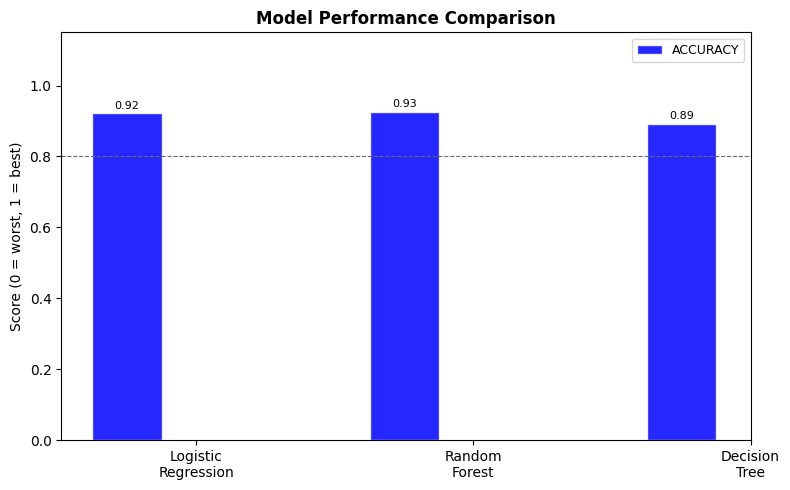

  Saved: chart1_model_performance.png

[Step 7] Generating charts...
  Saved: chart1_model_performance.png

[Step 7] Generating charts...
  Saved: chart1_model_performance.png


In [121]:
# Model performance chart
fig1, ax1 = plt.subplots(figsize=(8, 5))

model_names = list(results.keys())
x_positions = np.arange(len(model_names))   # [0, 1, 2]
bar_width   = 0.25
for i, (metric, colour, label) in enumerate([
        ("accuracy", "blue",     "ACCURACY"),
        ("f1",       "green","F1 SCORE"),
        ("roc_auc",  "orange",    "ROC-AUC"),
    ]):
        values = [results[m][metric] for m in model_names]
        bars = ax1.bar(
            x_positions + i * bar_width,
            values,
            bar_width,
            label=label,
            color=colour,
            alpha=0.85,
            edgecolor="white"
    )
        ax1.bar_label(bars, fmt="%.2f", fontsize=8, padding=2)
        ax1.set_xticks(x_positions + bar_width)
        ax1.set_xticklabels(
        [m.replace(" ", "\n") for m in model_names], fontsize=10
    )
        ax1.set_ylim(0, 1.15)
        ax1.set_title("Model Performance Comparison", fontsize=12, fontweight="bold")
        ax1.set_ylabel("Score (0 = worst, 1 = best)")
        ax1.legend(fontsize=9)
        ax1.axhline(0.80, color="dimgray", linestyle="--", linewidth=0.8,
                label="0.80 reference line")

        save_chart(fig1, "chart1_model_performance.png")

        


[Step 7] Generating charts...


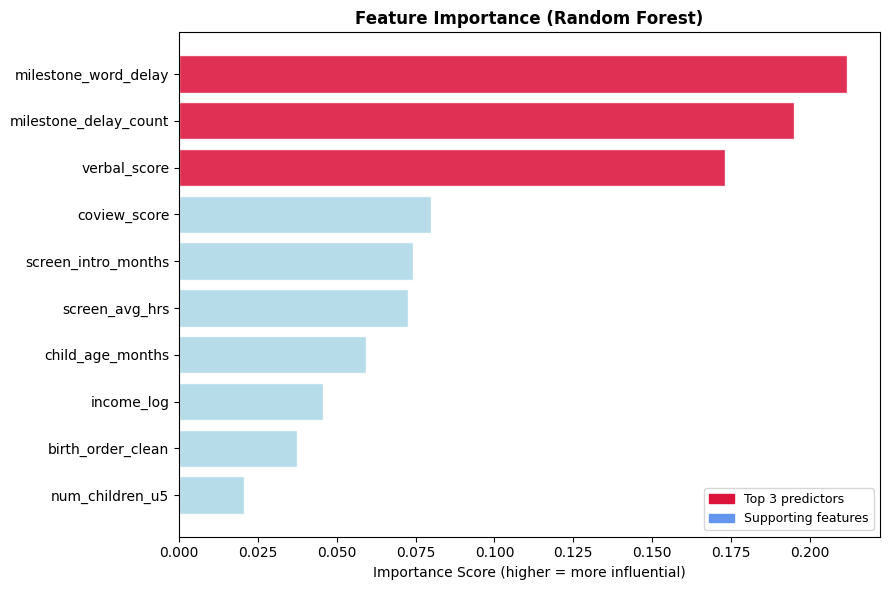

  Saved: chart2_feature_importance.png


In [122]:
# Feature performance chart
fig2, ax2 = plt.subplots(figsize=(9, 6))
top_10 = importance_df.head(10)
# Assign colour based on rank — top 3 get crimson, rest get blue
bar_colours = [
        "crimson" if i < 3 else "lightblue"
        for i in range(len(top_10))
    ]
# most important feature starts
ax2.barh(
        top_10["Feature"][::-1],
        top_10["Importance"][::-1],
        color=bar_colours[::-1],
        alpha=0.88,
        edgecolor="white"
    )

ax2.set_title("Feature Importance (Random Forest)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Importance Score (higher = more influential)")
ax2.legend(handles=[
        mpatches.Patch(color="crimson",        label="Top 3 predictors"),
        mpatches.Patch(color="cornflowerblue", label="Supporting features"),
    ], fontsize=9)

save_chart(fig2, "chart2_feature_importance.png")



[Step 7] Generating charts...


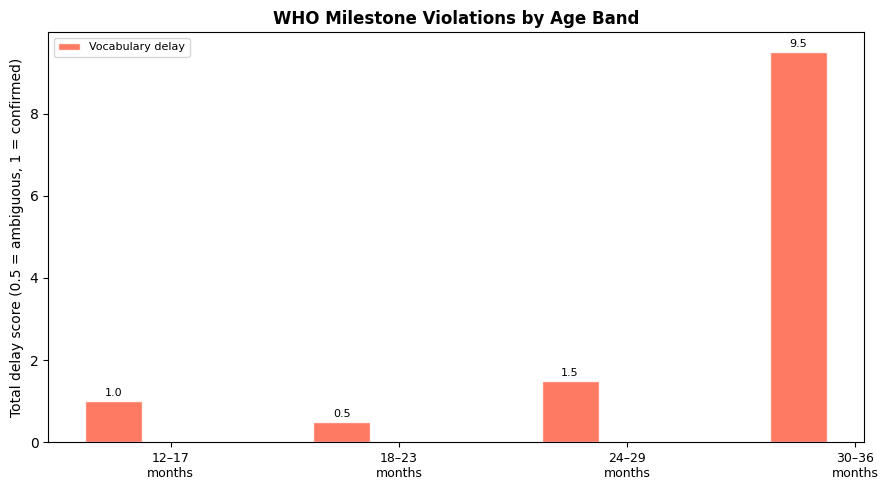

  Saved: chart3_who_milestones.png

[Step 7] Generating charts...
  Saved: chart3_who_milestones.png

[Step 7] Generating charts...
  Saved: chart3_who_milestones.png


In [123]:
# Milestones by age band
fig3, ax3 = plt.subplots(figsize=(9, 5))

age_bands  = ["12–17 months", "18–23 months", "24–29 months", "30–36 months"]
band_x     = np.arange(len(age_bands))
band_width = 0.25

for i, (delay_col, delay_label, colour) in enumerate([
        ("milestone_word_delay",    "Vocabulary delay",     "tomato"),
        ("milestone_combine_delay", "Word combining delay", "orange"),
        ("milestone_respond_delay", "Name response delay",  "mediumpurple"),
    ]):
# sum delay scores per age band
    counts = [
            df_model[df_model["milestone_band"] == band][delay_col].sum()
            for band in age_bands
        ]
    bars = ax3.bar(
            band_x + i * band_width,
            counts,
            band_width,
            label=delay_label,
            color=colour,
            alpha=0.85,
            edgecolor="white"
        )
    ax3.bar_label(bars, fmt="%.1f", fontsize=8, padding=2)

    ax3.set_xticks(band_x + band_width)
    ax3.set_xticklabels(
        [b.replace(" months", "\nmonths") for b in age_bands], fontsize=9
    )
    ax3.set_title("WHO Milestone Violations by Age Band", fontsize=12, fontweight="bold")
    ax3.set_ylabel("Total delay score (0.5 = ambiguous, 1 = confirmed)")
    ax3.legend(fontsize=8)

    save_chart(fig3, "chart3_who_milestones.png")

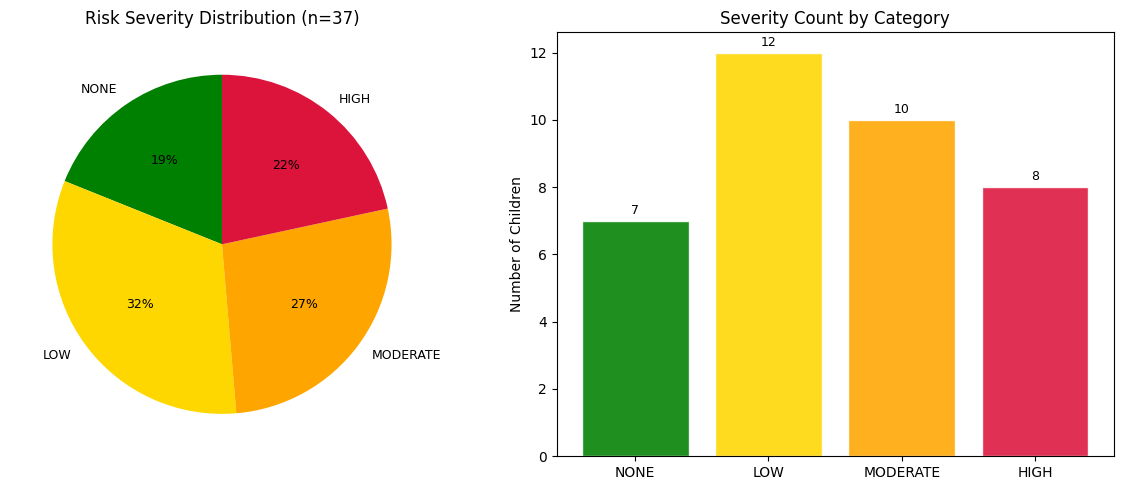

  Saved: chart4_severity_distribution.png


In [124]:
# Risk severity pie chart
severity_order   = ["NONE", "LOW", "MODERATE", "HIGH"]
severity_colours = {
    "NONE"    : "green",
    "LOW"     : "gold",
    "MODERATE": "orange",
    "HIGH"    : "crimson",
}
severity_counts = df_model["severity"].value_counts().to_dict()

fig4, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
severity_values = [severity_counts.get(s, 0) for s in severity_order]
ax.pie(severity_values, labels=severity_order,
           colors=[severity_colours[s] for s in severity_order],
           autopct="%1.0f%%", startangle=90,
           textprops={"fontsize": 9})
ax.set_title(f"Risk Severity Distribution (n={len(df_model)})")

ax2 = axes[1]
ax2.bar(severity_order,
        severity_values,
        color=[severity_colours[s] for s in severity_order],
        edgecolor="white", alpha=0.88)
ax2.set_title("Severity Count by Category")
ax2.set_ylabel("Number of Children")
for i, v in enumerate(severity_values):
    ax2.text(i, v + 0.2, str(v), ha="center", fontsize=9)

fig4.tight_layout()
fig4.savefig("chart4_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig4)
print("  Saved: chart4_severity_distribution.png")

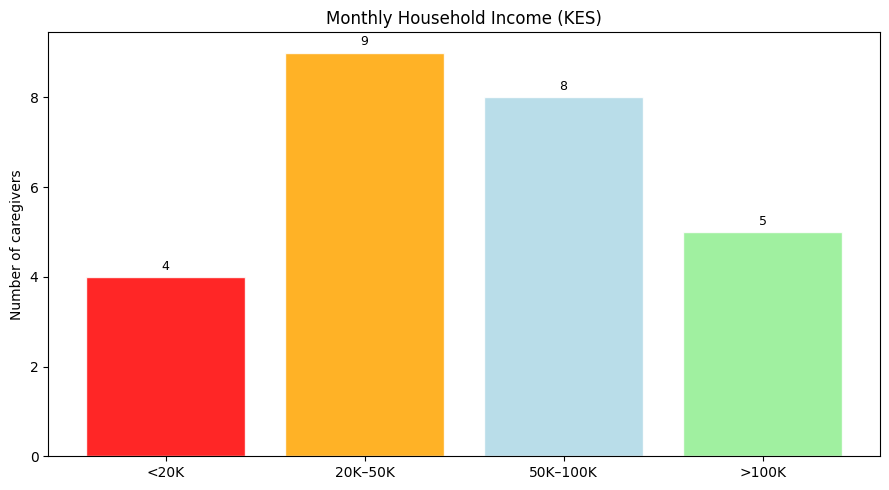

  Saved: chart5_income_distribution.png


In [125]:
# Prepare income data
fig5, axes = plt.subplots(figsize=(9, 5))

# Get cleaned income values from existing notebook data
if 'df_model' in globals() and 'income' in df_model.columns:
    income_data = df_model['income'].dropna()
elif 'df' in globals() and 'income' in df.columns:
    income_data = df['income'].dropna()
else:
    income_data = pd.Series(dtype=float)

# Bucket the income data
income_bins = [0, 20000, 50000, 100000, np.inf]
income_labels = ['<20K', '20K–50K', '50K–100K', '>100K']
bucket_counts = (
    pd.cut(income_data, bins=income_bins, labels=income_labels, include_lowest=True)
    .value_counts()
    .reindex(income_labels, fill_value=0)
)

ax = axes
if len(income_data) > 0:
    bars = ax.bar(
            income_labels, bucket_counts.values,
            color=["red", "orange", "lightblue", "lightgreen"],
            alpha=0.85, edgecolor="white"
        )
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title("Monthly Household Income (KES)")
    ax.set_ylabel("Number of caregivers")
else:
    ax.text(0.5, 0.5, "No income data", ha="center", va="center",
                transform=ax.transAxes)
    ax.set_title("Monthly Household Income (KES)")

fig5.tight_layout()
fig5.savefig("chart5_income_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig5)
print("  Saved: chart5_income_distribution.png")

In [ ]:
# Caregiver age chart
if 'df_model' in globals() and 'caregiver_age' in df_model.columns:
        age_data = df_model['caregiver_age'].dropna()
elif 'df' in globals() and 'caregiver_age' in df.columns:
        age_data = df['caregiver_age'].dropna()
else:
        age_data = pd.Series(dtype=float)

if isinstance(axes, np.ndarray):
        if axes.ndim == 2 and axes.shape[0] > 1 and axes.shape[1] > 2:
                ax = axes[1, 2]
        else:
                ax = axes.flat[0]
else:
        ax = axes

if len(age_data) > 0:
        ax.hist(age_data, bins=8, color="cornflowerblue",
                edgecolor="white", alpha=0.85)
        ax.axvline(age_data.median(), color="navy", linestyle="--",
                   linewidth=1.5, label=f"Median: {age_data.median():.0f} yrs")
        ax.set_title("Caregiver Age Distribution")
        ax.set_xlabel("Age (years)")
        ax.set_ylabel("Number of caregivers")
        ax.legend(fontsize=9)
else:
        ax.text(0.5, 0.5, "No age data available", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title("Caregiver Age Distribution")

fig_all = ax.figure
save_chart(fig_all, "speech_delay_results.png")

NameError: name 'fig_all' is not defined


[Step 7] Generating charts...


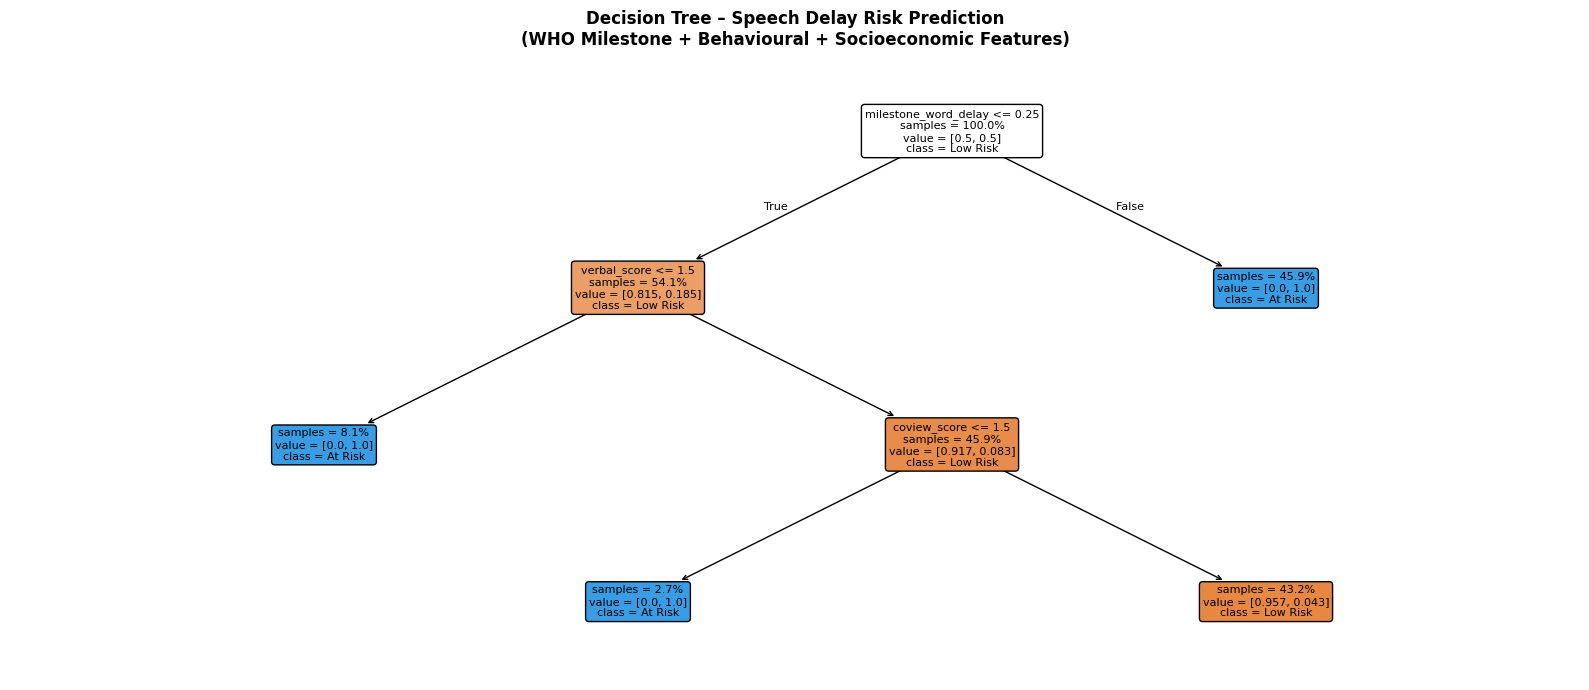

  Saved: speech_delay_decision_tree.png


In [56]:
# Decision tree visualization
imputer  = SimpleImputer(strategy="median")
X_filled = imputer.fit_transform(X)
viz_tree = DecisionTreeClassifier(
        max_depth=3, class_weight="balanced", random_state=42
    )
viz_tree.fit(X_filled, y)

fig_tree, ax_tree = plt.subplots(figsize=(16, 7))
plot_tree(
        viz_tree,
        feature_names=list(X.columns),
        class_names=["Low Risk", "At Risk"],
        filled=True,        # Colour nodes by majority class
        rounded=True,       # Round the node corners
        fontsize=8,
        ax=ax_tree,
        impurity=False,     # Hide Gini score — keeps diagram clean
        proportion=True     # Show class proportions instead of raw counts
    )
ax_tree.set_title(
        "Decision Tree – Speech Delay Risk Prediction\n"
        "(WHO Milestone + Behavioural + Socioeconomic Features)",
        fontsize=12, fontweight="bold"
    )

save_chart(fig_tree, "speech_delay_decision_tree.png")

In [57]:
# Comparative Charts

def make_comparative_charts(df_model):
    print("\n[Step 7B] Generating comparative charts...")
    # label children at risk vs low/ no risk
at_risk  = df_model[df_model["speech_delay_label"] == 1]
low_risk = df_model[df_model["speech_delay_label"] == 0]

n_at   = len(at_risk)
n_low  = len(low_risk)
# label colours for both groups
AT_COLOUR  = "crimson"
LOW_COLOUR = "steelblue"

# allow charts to be saved
def save_chart(figure, filename):
    figure.tight_layout()
    figure.savefig(filename, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figure)
    print(f"  Saved: {filename}")

# add percentages to bar labels
def add_bar_labels(ax, bars):
    """Add count labels on top of each bar."""
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.05,
                f"{int(h)}",
                ha="center", va="bottom", fontsize=9, fontweight="bold"
            )

# chart for categorical features
def grouped_bar(ax, categories, at_counts, low_counts,
                xlabel, title, rotation=0):
    x         = np.arange(len(categories))
    bar_width = 0.35

    bars_at  = ax.bar(x - bar_width/2, at_counts,  bar_width,
                      label=f"At-Risk (n={n_at})",
                      color=AT_COLOUR,  alpha=0.85, edgecolor="white")
    bars_low = ax.bar(x + bar_width/2, low_counts, bar_width,
                      label=f"Low-Risk (n={n_low})",
                      color=LOW_COLOUR, alpha=0.85, edgecolor="white")

    add_bar_labels(ax, bars_at)
    add_bar_labels(ax, bars_low)

    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=rotation,
                       ha="right" if rotation > 0 else "center", fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Number of children")
    ax.legend(fontsize=9)
    

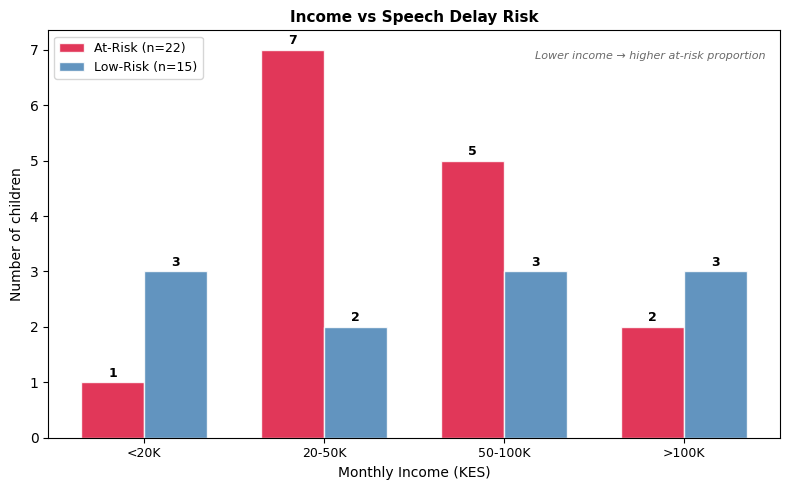

  Saved: comp1_income_vs_delay.png


In [58]:
# income vs speech delay risk
fig1, ax1 = plt.subplots(figsize=(8, 5))

income_bins   = [0, 20000, 50000, 100000, float("inf")]
income_labels = ["<20K", "20-50K", "50-100K", ">100K"]

# group income data for at-risk vs low-risk children
at_income  = pd.cut(at_risk["income"].dropna(),  bins=income_bins, labels=income_labels)
low_income = pd.cut(low_risk["income"].dropna(), bins=income_bins, labels=income_labels)

at_counts  = [at_income.value_counts().get(l, 0)  for l in income_labels]
low_counts = [low_income.value_counts().get(l, 0) for l in income_labels]

grouped_bar(ax1, income_labels, at_counts, low_counts,
                "Monthly Income (KES)",
                "Income vs Speech Delay Risk")
ax1.text(0.98, 0.95,
             "Lower income → higher at-risk proportion",
             transform=ax1.transAxes, ha="right", va="top",
             fontsize=8, color="dimgray", style="italic")

save_chart(fig1, "comp1_income_vs_delay.png")


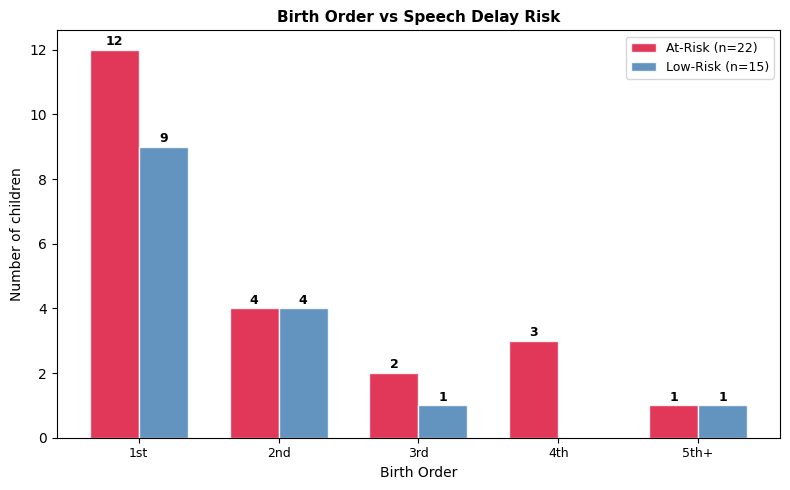

  Saved: comp2_birth_order_vs_delay.png


In [59]:
# Birth order vs speech delay risk
fig2, ax2 = plt.subplots(figsize=(8, 5))

birth_cats = ["1st", "2nd", "3rd", "4th", "5th+"]
birth_map  = {1: "1st", 2: "2nd", 3: "3rd", 4: "4th", 5: "5th+"}

at_birth  = at_risk["birth_order_clean"].map(birth_map).value_counts()
low_birth = low_risk["birth_order_clean"].map(birth_map).value_counts()

at_counts  = [at_birth.get(c, 0)  for c in birth_cats]
low_counts = [low_birth.get(c, 0) for c in birth_cats]

grouped_bar(ax2, birth_cats, at_counts, low_counts,
                "Birth Order",
                "Birth Order vs Speech Delay Risk")

save_chart(fig2, "comp2_birth_order_vs_delay.png")


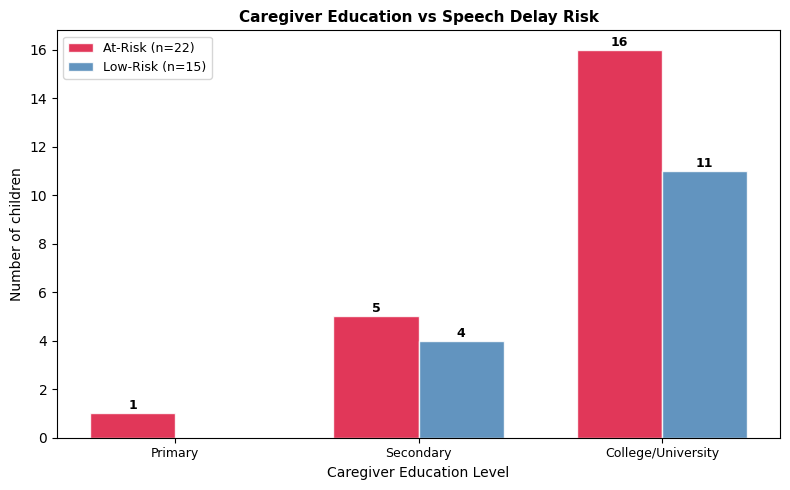

  Saved: comp3_education_vs_delay.png


In [60]:
# caregiver education vs speech delay risk
fig3, ax3 = plt.subplots(figsize=(8, 5))

edu_cats  = ["Primary", "Secondary", "College/University"]
edu_field = "education"

at_edu  = at_risk[edu_field].str.strip().value_counts()  if edu_field in df.columns else pd.Series()
low_edu = low_risk[edu_field].str.strip().value_counts() if edu_field in df.columns else pd.Series()

at_counts  = [at_edu.get(c, 0)  for c in edu_cats]
low_counts = [low_edu.get(c, 0) for c in edu_cats]

grouped_bar(ax3, edu_cats, at_counts, low_counts,
                "Caregiver Education Level",
                "Caregiver Education vs Speech Delay Risk")

save_chart(fig3, "comp3_education_vs_delay.png")

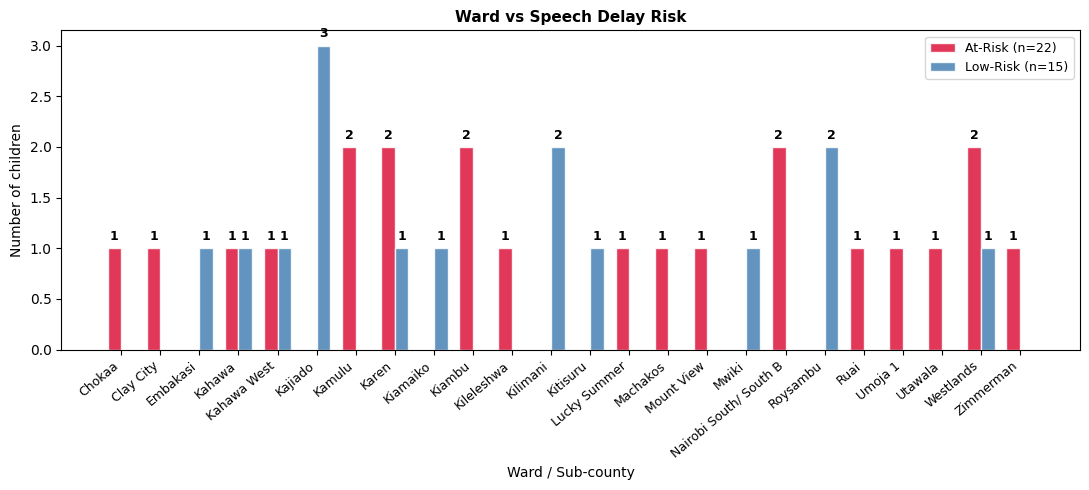

  Saved: comp4_ward_vs_delay.png


In [61]:
# Ward vs speech delay risk
fig4, ax4 = plt.subplots(figsize=(11, 5))

ward_field = "ward"
if ward_field in df.columns:
        # Get all wards 
        all_wards  = sorted(df[ward_field].dropna().unique())

        at_ward  = at_risk[ward_field].value_counts()
        low_ward = low_risk[ward_field].value_counts()

        at_counts  = [at_ward.get(w, 0)  for w in all_wards]
        low_counts = [low_ward.get(w, 0) for w in all_wards]

        grouped_bar(ax4, all_wards, at_counts, low_counts,
                    "Ward / Sub-county",
                    "Ward vs Speech Delay Risk",
                    rotation=40)
else:
        ax4.text(0.5, 0.5, "Ward data not available",
                 ha="center", va="center", transform=ax4.transAxes)
        ax4.set_title("Ward vs Speech Delay Risk")

save_chart(fig4, "comp4_ward_vs_delay.png")

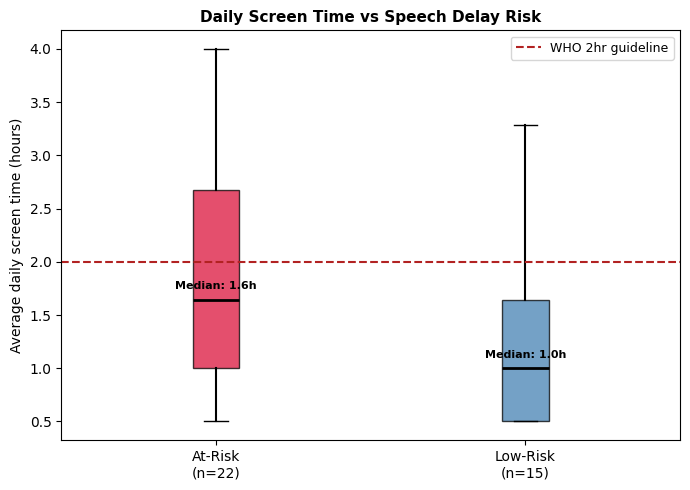

  Saved: comp5_screen_time_vs_delay.png


In [62]:
# Daily screen time vs speech delay risk
fig5, ax5 = plt.subplots(figsize=(7, 5))

screen_at  = at_risk["screen_avg_hrs"].dropna()
screen_low = low_risk["screen_avg_hrs"].dropna()

 # Box plot shows median, interquartile range, and outliers
bp = ax5.boxplot(
        [screen_at, screen_low],
        labels=[f"At-Risk\n(n={len(screen_at)})",
                f"Low-Risk\n(n={len(screen_low)})"],
        patch_artist=True,      # Fill boxes with colour
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=5, alpha=0.6)
    )

# Apply colours to each box
bp["boxes"][0].set_facecolor(AT_COLOUR)
bp["boxes"][0].set_alpha(0.75)
bp["boxes"][1].set_facecolor(LOW_COLOUR)
bp["boxes"][1].set_alpha(0.75)

# Add WHO 2-hour guideline as a dashed reference line
ax5.axhline(2, color="firebrick", linestyle="--", linewidth=1.5,
                label="WHO 2hr guideline")

ax5.set_title("Daily Screen Time vs Speech Delay Risk",
                  fontsize=11, fontweight="bold")
ax5.set_ylabel("Average daily screen time (hours)")
ax5.legend(fontsize=9)

 # Annotate with median values
for i, data in enumerate([screen_at, screen_low], 1):
    if len(data) > 0:
            ax5.text(i, data.median() + 0.1, f"Median: {data.median():.1f}h",
                     ha="center", fontsize=8, color="black", fontweight="bold")

save_chart(fig5, "comp5_screen_time_vs_delay.png")

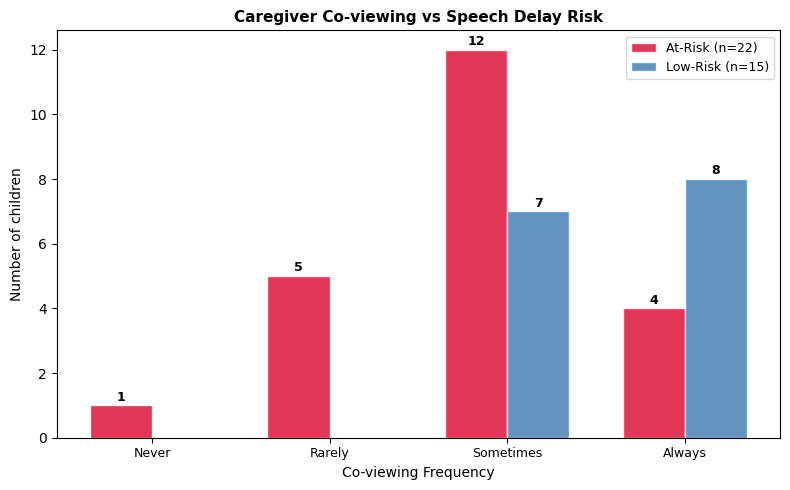

  Saved: comp6_coview_vs_delay.png


In [63]:
# co-viewing score vs speech delay risk
fig6, ax6 = plt.subplots(figsize=(8, 5))

coview_cats  = ["Never", "Rarely", "Sometimes", "Always"]
coview_map_r = {0: "Never", 1: "Rarely", 2: "Sometimes", 3: "Always"}

at_cv  = at_risk["coview_score"].map(coview_map_r).value_counts()
low_cv = low_risk["coview_score"].map(coview_map_r).value_counts()

at_counts  = [at_cv.get(c, 0)  for c in coview_cats]
low_counts = [low_cv.get(c, 0) for c in coview_cats]

grouped_bar(ax6, coview_cats, at_counts, low_counts,
                "Co-viewing Frequency",
                "Caregiver Co-viewing vs Speech Delay Risk")

save_chart(fig6, "comp6_coview_vs_delay.png")

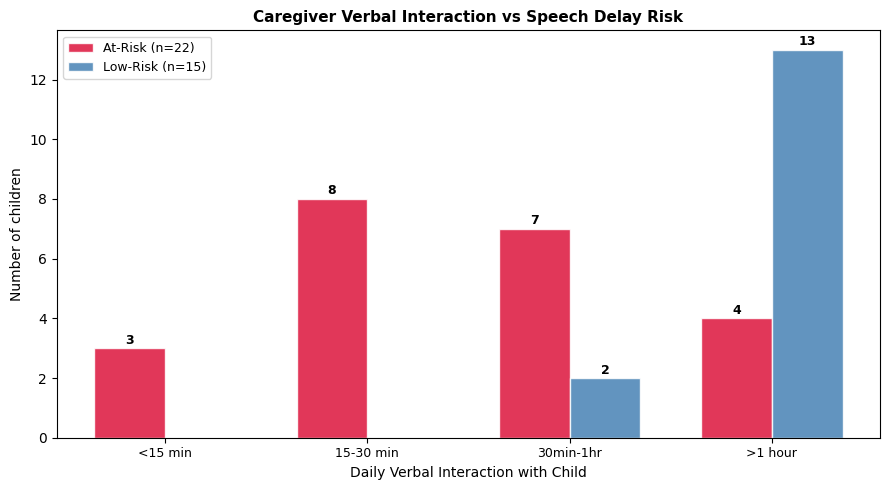

  Saved: comp7_verbal_interaction_vs_delay.png


In [64]:
# verbal interaction score vs speech delay risk
fig7, ax7 = plt.subplots(figsize=(9, 5))

verbal_cats = ["<15 min", "15-30 min", "30min-1hr", ">1 hour"]
verbal_map_r = {0: "<15 min", 1: "15-30 min", 2: "30min-1hr", 3: ">1 hour"}

at_vb  = at_risk["verbal_score"].map(verbal_map_r).value_counts()
low_vb = low_risk["verbal_score"].map(verbal_map_r).value_counts()

at_counts  = [at_vb.get(c, 0)  for c in verbal_cats]
low_counts = [low_vb.get(c, 0) for c in verbal_cats]

grouped_bar(ax7, verbal_cats, at_counts, low_counts,
                "Daily Verbal Interaction with Child",
                "Caregiver Verbal Interaction vs Speech Delay Risk")

save_chart(fig7, "comp7_verbal_interaction_vs_delay.png")

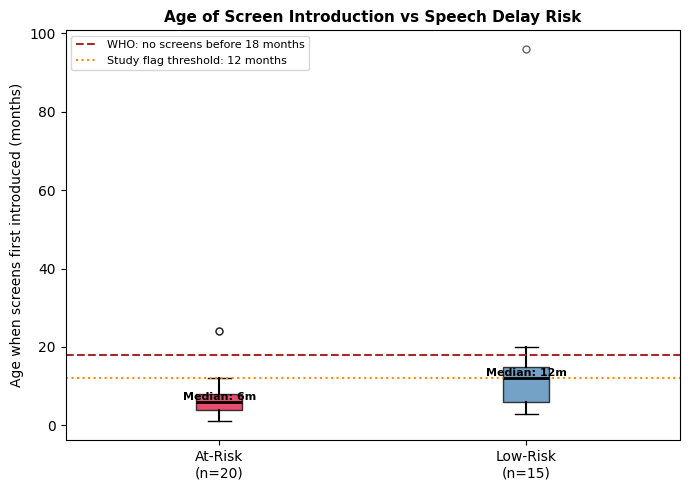

  Saved: comp8_screen_intro_vs_delay.png


In [65]:
# Age of screen introduction vs speech delay risk
fig8, ax8 = plt.subplots(figsize=(7, 5))

intro_at  = at_risk["screen_intro_months"].dropna()
intro_low = low_risk["screen_intro_months"].dropna()

bp2 = ax8.boxplot(
        [intro_at, intro_low],
        labels=[f"At-Risk\n(n={len(intro_at)})",
                f"Low-Risk\n(n={len(intro_low)})"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.5),
        flierprops=dict(marker="o", markersize=5, alpha=0.6)
    )

bp2["boxes"][0].set_facecolor(AT_COLOUR)
bp2["boxes"][0].set_alpha(0.75)
bp2["boxes"][1].set_facecolor(LOW_COLOUR)
bp2["boxes"][1].set_alpha(0.75)

    # WHO 18-month recommendation line
ax8.axhline(18, color="brown", linestyle="--", linewidth=1.5,
                label="WHO: no screens before 18 months")

    # Study's flag threshold
ax8.axhline(12, color="darkorange", linestyle=":", linewidth=1.5,
                label="Study flag threshold: 12 months")

ax8.set_title("Age of Screen Introduction vs Speech Delay Risk",
                  fontsize=11, fontweight="bold")
ax8.set_ylabel("Age when screens first introduced (months)")
ax8.legend(fontsize=8)

for i, data in enumerate([intro_at, intro_low], 1):
        if len(data) > 0:
            ax8.text(i, data.median() + 0.5, f"Median: {data.median():.0f}m",
                     ha="center", fontsize=8, fontweight="bold")

save_chart(fig8, "comp8_screen_intro_vs_delay.png")


  Conclusion dashboard...


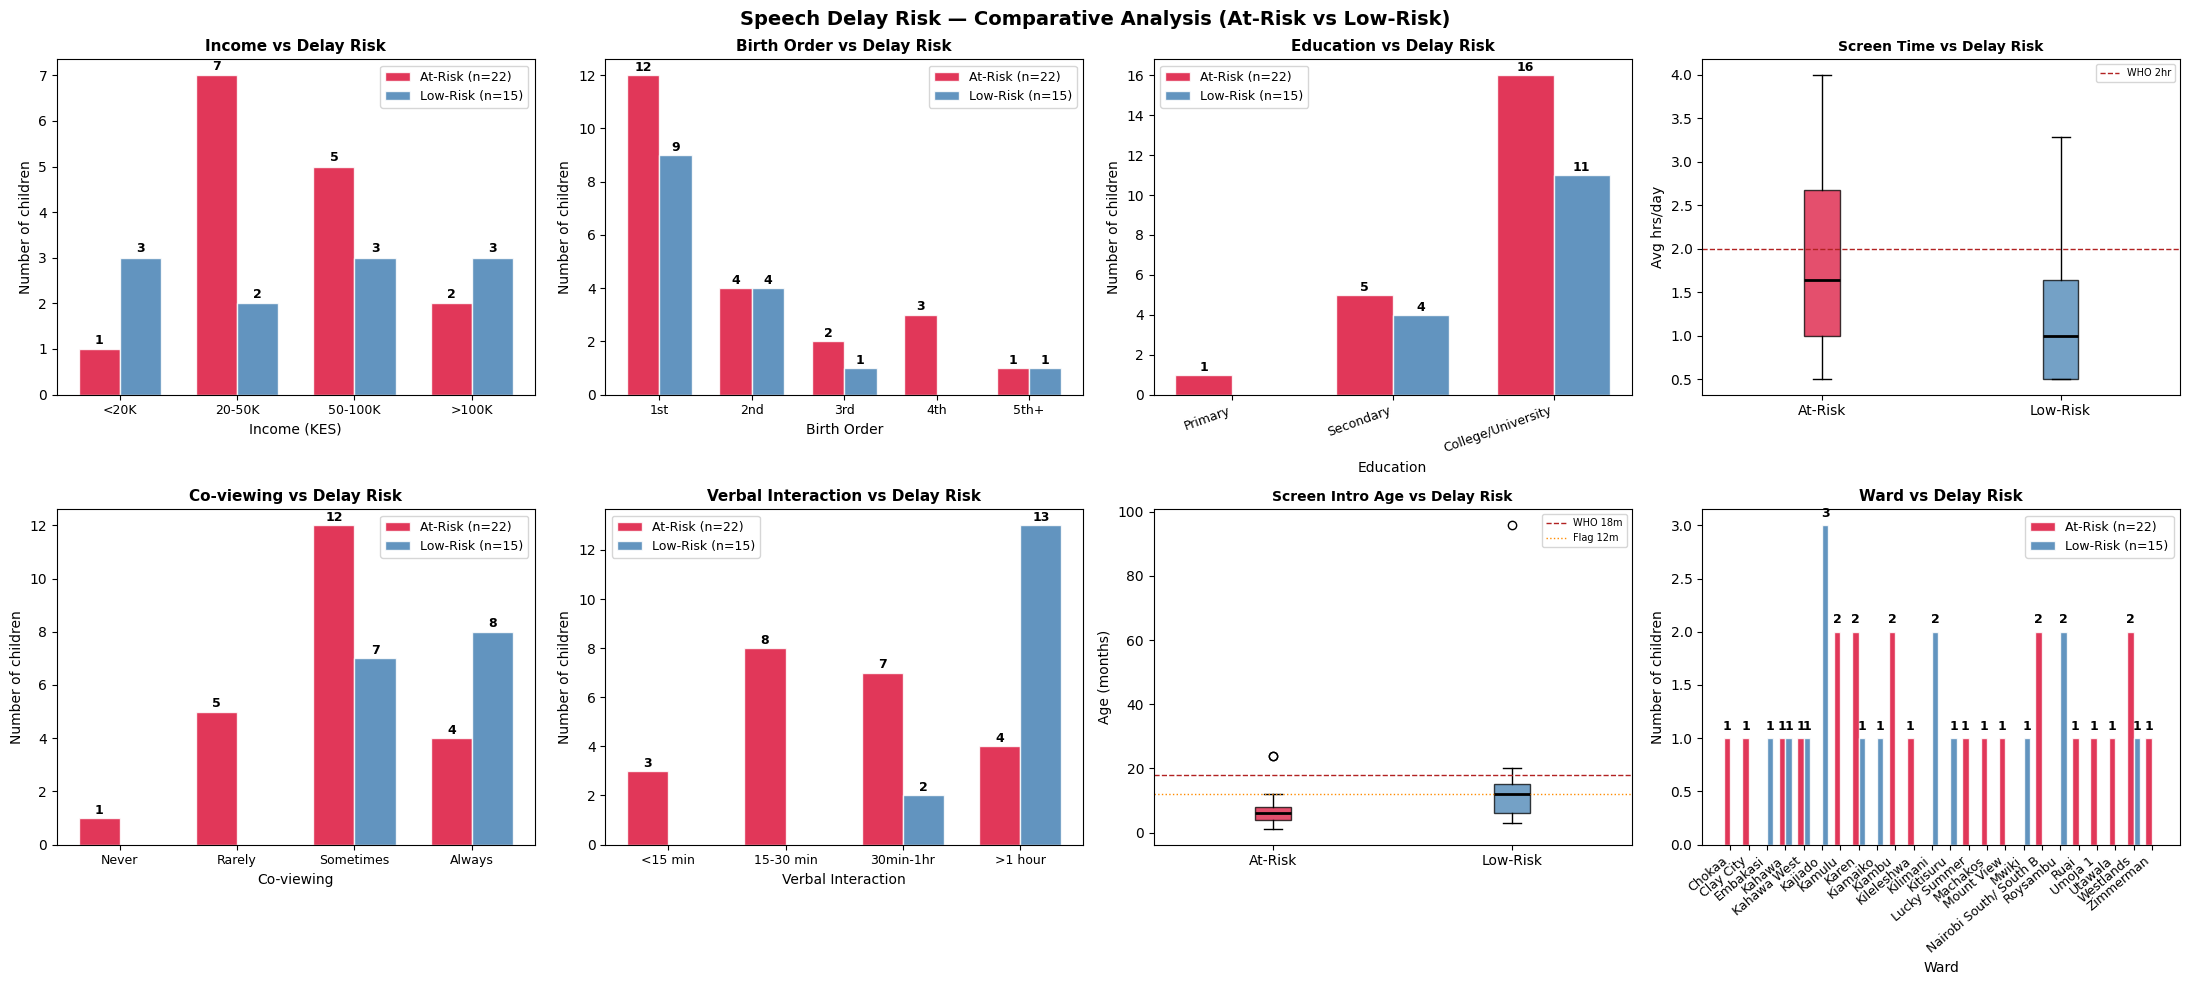

  Saved: comp_dashboard.png
  Comparative charts complete.


In [66]:
# Build Conclusion Chart
print("  Conclusion dashboard...")

fig_dash, axes = plt.subplots(2, 4, figsize=(22, 10), squeeze=False)
    # squeeze=False — same protection as the main dashboard above
fig_dash.suptitle(
        "Speech Delay Risk — Comparative Analysis (At-Risk vs Low-Risk)",
        fontsize=14, fontweight="bold"
    )

    # Income ───────────────────────────────────────────────
ax = axes[0, 0]
grouped_bar(ax, income_labels, at_counts := [at_income.value_counts().get(l, 0) for l in income_labels],
                [low_income.value_counts().get(l, 0) for l in income_labels],
                "Income (KES)", "Income vs Delay Risk")

    # Birth order ──────────────────────────────────────────
ax = axes[0, 1]
grouped_bar(ax, birth_cats,
                [at_birth.get(c, 0) for c in birth_cats],
                [low_birth.get(c, 0) for c in birth_cats],
                "Birth Order", "Birth Order vs Delay Risk")

    # Education ────────────────────────────────────────────
ax = axes[0, 2]
grouped_bar(ax, edu_cats,
                [at_edu.get(c, 0) for c in edu_cats],
                [low_edu.get(c, 0) for c in edu_cats],
                "Education", "Education vs Delay Risk", rotation=20)

    # Screen time ─────────────────────────────────────────────
ax = axes[0, 3]
bp3 = ax.boxplot(
        [screen_at, screen_low],
        labels=["At-Risk", "Low-Risk"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
bp3["boxes"][0].set_facecolor(AT_COLOUR);  bp3["boxes"][0].set_alpha(0.75)
bp3["boxes"][1].set_facecolor(LOW_COLOUR); bp3["boxes"][1].set_alpha(0.75)
ax.axhline(2, color="firebrick", linestyle="--", linewidth=1, label="WHO 2hr")
ax.set_title("Screen Time vs Delay Risk", fontsize=10, fontweight="bold")
ax.set_ylabel("Avg hrs/day")
ax.legend(fontsize=7)

    # Co-viewing ───────────────────────────────────────────
ax = axes[1, 0]
grouped_bar(ax, coview_cats,
                [at_cv.get(c, 0) for c in coview_cats],
                [low_cv.get(c, 0) for c in coview_cats],
                "Co-viewing", "Co-viewing vs Delay Risk")

    # Verbal interaction ───────────────────────────────────
ax = axes[1, 1]
grouped_bar(ax, verbal_cats,
                [at_vb.get(c, 0) for c in verbal_cats],
                [low_vb.get(c, 0) for c in verbal_cats],
                "Verbal Interaction", "Verbal Interaction vs Delay Risk")

    # Screen introduction ─────────────────────────────────────────────
ax = axes[1, 2]
bp4 = ax.boxplot(
        [intro_at, intro_low],
        labels=["At-Risk", "Low-Risk"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
bp4["boxes"][0].set_facecolor(AT_COLOUR);  bp4["boxes"][0].set_alpha(0.75)
bp4["boxes"][1].set_facecolor(LOW_COLOUR); bp4["boxes"][1].set_alpha(0.75)
ax.axhline(18, color="firebrick", linestyle="--", linewidth=1, label="WHO 18m")
ax.axhline(12, color="darkorange", linestyle=":", linewidth=1, label="Flag 12m")
ax.set_title("Screen Intro Age vs Delay Risk", fontsize=10, fontweight="bold")
ax.set_ylabel("Age (months)")
ax.legend(fontsize=7)

    # Ward ─────────────────────────────────────────────────
ax = axes[1, 3]
if ward_field in df.columns:
        grouped_bar(ax, all_wards,
                    [at_ward.get(w, 0) for w in all_wards],
                    [low_ward.get(w, 0) for w in all_wards],
                    "Ward", "Ward vs Delay Risk", rotation=40)
else:
        ax.text(0.5, 0.5, "Ward data\nnot available",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title("Ward vs Delay Risk")

fig_dash.tight_layout()
fig_dash.savefig("comp_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig_dash)
print("  Saved: comp_dashboard.png")
print("  Comparative charts complete.")



In [67]:
# Prediction function for new data on web interface
def predict_new_child(trained_model, fitted_imputer, feature_names, child_data):
    # convert raw yes/no responses to 1/0
    def yes_no(value):
        """Convert Yes/No text to 1/0."""
        return 1 if str(value).strip().lower() == "yes" else 0

    combines_bin = yes_no(child_data.get("combines_words", "No"))
    responds_bin = yes_no(child_data.get("responds_to_name", "Yes"))
    concern_bin = yes_no(child_data.get("concern_raised", "No"))

    # clean numeric inputs
    child_age = float(child_data.get("child_age_months", 0))
    screen_intro = clean_screen_intro(child_data.get("screen_intro_age", np.nan))
    screen_wd_hrs = clean_screen_time(child_data.get("screen_weekday", np.nan))
    screen_we_hrs = clean_screen_time(child_data.get("screen_weekend", np.nan))
    verbal_score = VERBAL_INTERACTION_MAP.get(
        str(child_data.get("verbal_interaction", "")).strip().lower(), np.nan
    )
    coview_score = CO_VIEW_MAP.get(
        str(child_data.get("co_view", "")).strip().lower(), np.nan
    )

    # Weighted average screen time: (weekday x 5 + weekend x 2) / 7
    screen_wd_hrs = screen_wd_hrs if not pd.isna(screen_wd_hrs) else 0
    screen_we_hrs = screen_we_hrs if not pd.isna(screen_we_hrs) else 0
    screen_avg = (screen_wd_hrs * 5 + screen_we_hrs * 2) / 7

    # Education level
    education_map = {"primary": 0, "secondary": 1, "college/university": 2}
    education_ord = education_map.get(
        str(child_data.get("education", "")).strip().lower(), np.nan
    )

    # Gender binary
    gender_bin = 1 if str(child_data.get("child_gender", "")).strip().lower() == "male" else 0

    # Birth order — cap at 5
    birth_order = min(float(child_data.get("birth_order", 1)), 5)

    # Number of children under 5
    num_u5 = float(child_data.get("num_children_u5", 1))

    # Income
    income_raw = child_data.get("income", np.nan)
    try:
        income_val = float(income_raw) if income_raw else np.nan
        income_log = np.log10(income_val) if (income_val and income_val > 0) else np.nan
    except (ValueError, TypeError):
        income_log = np.nan
    # WHO milestone check
    milestone_row = {
        "child_age_months": child_age,
        "word_count_range": child_data.get("word_count_range", np.nan),
        "combines_words_bin": combines_bin,
        "responds_to_name_bin": responds_bin,
    }
    milestone_flags = check_milestone_flags(milestone_row)

    # behavioural flags
    flag_concern = concern_bin
    flag_excess_screen = int(screen_avg > 2)
    flag_low_verbal = int(verbal_score <= 1) if not pd.isna(verbal_score) else 0
    flag_early_screen = int(screen_intro < 12) if not pd.isna(screen_intro) else 0

    behavioural_flags = {
        "flag_concern": flag_concern,
        "flag_excess_screen": flag_excess_screen,
        "flag_low_verbal": flag_low_verbal,
        "flag_early_screen": flag_early_screen,
        "total_flags": flag_concern + flag_excess_screen + flag_low_verbal + flag_early_screen,
    }

    # Features raw
    raw_features = {
        "milestone_word_delay": milestone_flags["milestone_word_delay"],
        "milestone_combine_delay": milestone_flags["milestone_combine_delay"],
        "milestone_respond_delay": milestone_flags["milestone_respond_delay"],
        "milestone_delay_count": milestone_flags["milestone_delay_count"],
        "screen_avg_hrs": screen_avg,
        "screen_intro_months": screen_intro,
        "verbal_score": verbal_score,
        "coview_score": coview_score,
        "flag_concern": flag_concern,
        "flag_early_screen": flag_early_screen,
        "child_age_months": child_age,
        "gender_bin": gender_bin,
        "birth_order_clean": birth_order,
        "num_children_u5": num_u5,
        "education_ord": education_ord,
        "income_log": income_log,
    }

    row_df = pd.DataFrame([{f: raw_features.get(f, np.nan) for f in feature_names}])
    row_imp = fitted_imputer.transform(row_df)

    # Predict probability of being at risk
    probability = trained_model.predict_proba(row_imp)[0][1]

    if probability >= 0.60:
        risk_level = "HIGH RISK"
        recommendation = (
            "Refer to a speech therapist urgently. "
            "Reduce screen time to below 2 hours per day. "
            "Increase talking, reading, and singing to over 1 hour per day."
        )
    elif probability >= 0.35:
        risk_level = "MODERATE RISK"
        recommendation = (
            "Monitor closely. Schedule a speech assessment within 1-2 months. "
            "Reduce screen time and increase caregiver verbal interaction."
        )
    else:
        risk_level = "LOW RISK"
        recommendation = (
            "Continue current caregiver engagement. "
            "Return for a follow-up check in 2-3 months."
        )

    # WHO band data
    _, band_data = get_milestone_band(int(child_age))
    who_minimum = band_data["min_words"] if band_data else None

    # return a structured result
    return {
        "probability"       : round(float(probability), 4),
        "probability_pct"   : f"{probability:.0%}",
        "risk_level"        : risk_level,
        "recommendation"    : recommendation,
        "milestone_flags"   : milestone_flags,
        "behavioural_flags" : behavioural_flags,
        "who_minimum"       : who_minimum,
        "milestone_band"    : milestone_flags.get("milestone_band", "Unknown"),
        "screen_avg_hrs"    : round(screen_avg, 2),
        "screen_exceeds_who": bool(screen_avg > 2),
    }


def run_demo_prediction(trained_model, fitted_imputer, feature_names):
    # Example child data for prediction
    example_child = {
        "child_age_months"  : 24,
        "word_count_range"  : "5 - 20",     
        "combines_words"    : "No",          
        "responds_to_name"  : "Yes",         
        "screen_weekday"    : "3 hours",     
        "screen_weekend"    : "4 hours",
        "screen_intro_age"  : "6",           
        "verbal_interaction": "less than 15 min",  
        "co_view"           : "sometimes",
        "concern_raised"    : "No",
        "birth_order"       : 2,
        "num_children_u5"   : 2,
        "education"         : "secondary",
        "child_gender"      : "Male",
        "income"            : 35000,
    }
    result = predict_new_child(
        trained_model, fitted_imputer, feature_names, example_child
    )
    # Display the prediction result
    m = result["milestone_flags"]
    b = result["behavioural_flags"]

    print(f"\n{'=' * 60}")
    print(f"  DEMO PREDICTION REPORT")
    print(f"  (Example child — not real data)")
    print(f"{'=' * 60}")
    print(f"  Child age    : {example_child['child_age_months']} months  |  "
          f"Band: {result['milestone_band']}")
    print()
    print(f"  WHO MILESTONE CHECKS")
    print(f"  {'-' * 50}")

    vocab_icon = "✓" if m["milestone_word_delay"] == 0.0 else (
                 "?" if m["milestone_word_delay"] == 0.5 else "✗")
    comb_icon  = "✓" if m["milestone_combine_delay"] == 0 else "✗"
    resp_icon  = "✓" if m["milestone_respond_delay"] == 0 else "✗"

    print(f"  {vocab_icon} Vocabulary    : {m['word_status']}"
          f"  (score={m['milestone_word_delay']})")
    if result["who_minimum"]:
        print(f"               WHO minimum for this band: "
              f"{result['who_minimum']} words")
    print(f"  {comb_icon} Word combining: {m['combine_status']}"
          f"  (score={m['milestone_combine_delay']})")
    print(f"  {resp_icon} Name response : {m['respond_status']}"
          f"  (score={m['milestone_respond_delay']})")
    print(f"  {'-' * 50}")
    print(f"  Total milestone delay score : {m['milestone_delay_count']} / 3")
    print()
    print(f"  BEHAVIOURAL FLAGS  ({b['total_flags']} / 4 triggered)")
    print(f"  {'-' * 50}")
    print(f"  {'⚠' if b['flag_excess_screen'] else '✓'} Excess screen time   : "
          f"{'Yes — ' + str(result['screen_avg_hrs']) + ' hrs/day' if b['flag_excess_screen'] else 'No'}")
    print(f"  {'⚠' if b['flag_low_verbal']    else '✓'} Low verbal input     : "
          f"{'Yes' if b['flag_low_verbal'] else 'No'}")
    print(f"  {'⚠' if b['flag_early_screen']  else '✓'} Early screen intro   : "
          f"{'Yes' if b['flag_early_screen'] else 'No'}")
    print(f"  {'⚠' if b['flag_concern']       else '✓'} Professional concern : "
          f"{'Yes' if b['flag_concern'] else 'No'}")
    print()
    print(f"  Probability of speech delay : {result['probability_pct']}")
    print(f"  Risk level                  : {result['risk_level']}")
    print()
    print(f"  Recommendation:")
    print(f"  {result['recommendation']}")
    print(f"{'=' * 60}")
    print()
    print("  HOW THE WEB INTERFACE USES THIS FUNCTION:")
    print("  ─────────────────────────────────────────")
    print("  result = predict_new_child(model, imputer, features, form_data)")
    print("  return jsonify(result)   # sends to browser as JSON")


In [71]:
# Main Execution
if __name__ == '__main__':
    print("=" * 60)
    print("  SPEECH DELAY PREDICTION MODEL ")
    print("=" * 60)
    # Load and prepare data
    def load_data(filepath):
      df = pd.read_csv()
    ...
    df = clean_data(df)
    df = engineer_label(df)
    X, y, feature_names = prepare_features(df)
    # Ensure samples are sufficient for training
if len(X) < 10:
        print("\n  Not enough data yet (minimum 10 samples needed).")
        print("  Keep collecting responses and run again.")

else: 
    results, models = train_and_evaluate(X, y)
    importance_df = get_feature_importance(X, y, feature_names)
    make_charts(results, importance_df, X, y, df)
    make_comparative_charts(df)
    # Train final model on all data for web interface use
    from sklearn.impute import SimpleImputer
    final_imputer = SimpleImputer(strategy="median")
    X_filled      = final_imputer.fit_transform(X)
    final_model   = RandomForestClassifier(
    n_estimators=200, class_weight="balanced", random_state=42
        )
    final_model.fit(X_filled, y)
# Run a demo prediction with example data
    run_demo_prediction(final_model, final_imputer, feature_names)
print


  SPEECH DELAY PREDICTION MODEL 

[Step 3] Applying WHO milestones and engineering labels...
  At-risk : 22 (59%)
  Low-risk: 15 (41%)
  Severity breakdown: {'LOW': 12, 'MODERATE': 10, 'HIGH': 8, 'NONE': 7}

[Step 4] Preparing features...
  Income (log10): 26 values transformed, 11 missing (will be imputed with median log-income)
  14 features · 37 usable samples.

[Step 5] Training models with cross-validation...
  Logistic Regression: Accuracy=0.92±0.06  F1=0.93  ROC-AUC=0.97
  Random Forest: Accuracy=0.93±0.10  F1=0.94  ROC-AUC=0.99
  Decision Tree: Accuracy=0.89±0.05  F1=0.91  ROC-AUC=0.89

[Step 6] Computing feature importance (Random Forest)...
                Feature  Importance
   milestone_word_delay    0.211682
  milestone_delay_count    0.194911
           verbal_score    0.173004
           coview_score    0.079791
    screen_intro_months    0.074245
         screen_avg_hrs    0.072478
       child_age_months    0.059144
             income_log    0.045690
      birth_order

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [72]:
# save and download cleaned dataset for future use
cleaned_filepath = "cleaned_speech_delay_data.csv"
df.to_csv(cleaned_filepath, index=False)